# Active Torque on Rigid Bodies

## Overview

### Questions

* How can we apply an active torque to an arbitrary rigid body for use in HOOMD-blue?

### Objectives

* Define a **rigid body** as **central particle** and a set of constituent particles in a lattice. 
* Understand how to model **rotationally driven active matter systems** by applying an **active torque** to the rigid body.

## Boilerplate Code

In [1]:
import hoomd
import itertools

import gsd.hoomd

import numpy as np

In [2]:
import os

fn = os.path.join(os.getcwd(), "lattice.gsd")
![ -e "$fn" ] && rm "$fn"
fn = os.path.join(os.getcwd(), "active_torque.gsd")
![ -e "$fn" ] && rm "$fn"

The `render_rigid_body` function in the next (hidden) cell will render the rigid body using 
**fresnel**. Find the source in the [hoomd-examples](https://github.com/glotzerlab/hoomd-examples) repository.

In [3]:
# This is not intended as a full tutorial on fresnel - see the fresnel user
# documentation (https://fresnel.readthedocs.io/) if you would like to learn more.

import warnings
import fresnel
import IPython
import packaging.version
import os
import warnings


device = fresnel.Device()
tracer = fresnel.tracer.Path(device=device, w=300, h=300)

FRESNEL_MIN_VERSION = packaging.version.parse("0.13.0")
FRESNEL_MAX_VERSION = packaging.version.parse("0.14.0")


def render(snapshot):
    if (
        "version" not in dir(fresnel)
        or packaging.version.parse(fresnel.version.version) < FRESNEL_MIN_VERSION
        or packaging.version.parse(fresnel.version.version) >= FRESNEL_MAX_VERSION
    ):
        warnings.warn(
            f"Unsupported fresnel version {fresnel.version.version} - expect errors."
        )
    central_color = fresnel.color.linear([252 / 255, 41 / 255, 0 / 255])
    constituent_color = fresnel.color.linear([93 / 255, 210 / 255, 252 / 255])

    L = snapshot.configuration.box[0]
    scene = fresnel.Scene(device)
    geometry = fresnel.geometry.Sphere(
        scene, N=len(snapshot.particles.position), radius=0.5
    )
    geometry.material = fresnel.material.Material(
        color=[0, 0, 0], roughness=0.5, primitive_color_mix=1.0
    )
    geometry.position[:] = snapshot.particles.position[:]
    geometry.color[snapshot.particles.typeid[:] == 0] = central_color
    geometry.radius[snapshot.particles.typeid[:] == 0] = 0.3
    geometry.color[snapshot.particles.typeid[:] == 1] = constituent_color
    geometry.outline_width = 0.04
    fresnel.geometry.Box(scene, [L, L, L, 0, 0, 0], box_radius=0.02)

    scene.lights = [
        fresnel.light.Light(direction=(0, 0, 1), color=(0.8, 0.8, 0.8), theta=np.pi),
        fresnel.light.Light(
            direction=(1, 1, 1), color=(1.1, 1.1, 1.1), theta=np.pi / 3
        ),
    ]
    scene.camera = fresnel.camera.Orthographic(
        position=(L * 2, L, L * 2), look_at=(0, 0, 0), up=(0, 1, 0), height=L * 1.4 + 1
    )
    scene.background_alpha = 1
    scene.background_color = (1, 1, 1)
    samples = 2000
    if "CI" in os.environ:
        samples = 100
    return IPython.display.Image(tracer.sample(scene, samples=samples)._repr_png_())

    
def render_movie(frames, particles=None, is_solid=None):
    if is_solid is None:
        is_solid = [None] * len(frames)
    a = render(frames[0], particles, is_solid[0])

    im0 = PIL.Image.fromarray(a[:, :, 0:3], mode="RGB").convert(
        "P", palette=PIL.Image.Palette.ADAPTIVE
    )
    ims = []
    for i, f in enumerate(frames[1:]):
        a = render(f, particles, is_solid[i])
        im = PIL.Image.fromarray(a[:, :, 0:3], mode="RGB")
        im_p = im.quantize(palette=im0)
        ims.append(im_p)

    blank = np.ones(shape=(im.height, im.width, 3), dtype=np.uint8) * 255
    im = PIL.Image.fromarray(blank, mode="RGB")
    im_p = im.quantize(palette=im0)
    ims.append(im_p)

    f = io.BytesIO()
    im0.save(f, "gif", save_all=True, append_images=ims, duration=1000, loop=0)

    size = len(f.getbuffer()) / 1024
    if size > 3000:
        warnings.warn(f"Large GIF: {size} KiB")
    return IPython.display.display(IPython.display.Image(data=f.getvalue()))

device = fresnel.Device()
tracer = fresnel.tracer.Path(device=device, w=300, h=300)

FRESNEL_MIN_VERSION = packaging.version.parse("0.13.0")
FRESNEL_MAX_VERSION = packaging.version.parse("0.14.0")

def render_rigid_body(pos_body, radius_constituent=1):
    if (
        "version" not in dir(fresnel)
        or packaging.version.parse(fresnel.version.version) < FRESNEL_MIN_VERSION
        or packaging.version.parse(fresnel.version.version) >= FRESNEL_MAX_VERSION
    ):
        warnings.warn(
            f"Unsupported fresnel version {fresnel.version.version} - expect errors."
        )

    L = 3 * np.max(np.linalg.norm(pos_body, axis=1))
    scene = fresnel.Scene(device)
    geometry = fresnel.geometry.Sphere(
        scene, N=len(pos_body), radius=radius_constituent
    )
    geometry.material = fresnel.material.Material(
        color=fresnel.color.linear([93 / 255, 210 / 255, 252 / 255]), roughness=0.5
    )
    geometry.position[:] = pos_body
    geometry.outline_width = 0.04
    fresnel.geometry.Box(scene, [L, L, L, 0, 0, 0], box_radius=0.02)

    scene.lights = [
        fresnel.light.Light(direction=(0, 0, 1), color=(0.8, 0.8, 0.8), theta=math.pi),
        fresnel.light.Light(
            direction=(1, 1, 1), color=(1.1, 1.1, 1.1), theta=math.pi / 3
        ),
    ]
    scene.camera = fresnel.camera.Orthographic(
        position=(L * 2, L, L * 2), look_at=(0, 0, 0), up=(0, 1, 0), height=L * 1.4 + 1
    )
    scene.background_alpha = 1
    scene.background_color = (1, 1, 1)
    samples = 2000
    if "CI" in os.environ:
        samples = 100
    return IPython.display.Image(tracer.sample(scene, samples=samples)._repr_png_())

# Set up the Simulation 

This tutorial demonstrates how to simulate active Brownian particles using HOOMD-blue, with a system where **only active torque** is applied. These particles are modeled as **rigid bodies** with no translational self-propulsion or thermal fluctuations. We will first initialize a system of rigid bodies with a given particle density, in an array. Details for this can be found in the [Modeling-Rigid-Bodies](https://github.com/glotzerlab/hoomd-examples/tree/activity-tutorial/06-Modelling-Rigid-Bodies) repository. 

We create an initial configuration of dimers. Start with a frame containing both particle types:


In [4]:
m = 4
N_particles = m**3
spacing = 5
K = np.ceil(N_particles ** (1 / 3))
L = K * spacing
x = np.linspace(-L / 2, L / 2, int(K), endpoint=False)
position = list(itertools.product(x, repeat=3))
position = np.array(position) + [spacing / 2, spacing / 2, spacing / 2]

frame = gsd.hoomd.Frame()
frame.particles.N = N_particles
frame.particles.position = position[0:N_particles, :]
frame.particles.typeid = [0] * N_particles
frame.configuration.box = [L, L, L, 0, 0, 0]
frame.particles.types = ["dimer", "A"]
frame.particles.mass = [2] * N_particles 
frame.particles.orientation = [(1, 0, 0, 0)] * N_particles


Compute the moment of inertia of the dimer. Computing this is essential to accurate rotational updating of the rigid body. 

In [5]:
particle_mass = 1
particle_radius = 1
dimer_positions = [[1.2, 0, 0], [-1.2, 0, 0]]
I = np.zeros(shape=(3, 3))
for r in dimer_positions:
    I += particle_mass * (np.dot(r, r) * np.identity(3) - np.outer(r, r))
frame.particles.moment_inertia = [I[0, 0], I[1, 1], I[2, 2]] * N_particles

Write the rigid centers to a GSD file for later use:

In [6]:
with gsd.hoomd.open(name="lattice.gsd", mode="w") as f:
    f.append(frame)

Configure this simulation to run on CPU from this snapshot as we have in previous tutorials. Here, we also set the constituent particle properties in body coordinates for the rigid body type and visualize the rigid bodies in frame:

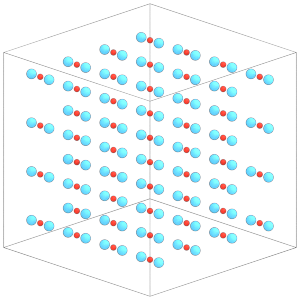

In [7]:
simulation = hoomd.Simulation(device=hoomd.device.CPU(), seed=1)
state = simulation.create_state_from_gsd(filename="lattice.gsd")

rigid = hoomd.md.constrain.Rigid()
rigid.body["dimer"] = {
    "constituent_types": ["A", "A"],
    "positions": dimer_positions,
    "orientations": [(1.0, 0.0, 0.0, 0.0), (1.0, 0.0, 0.0, 0.0)],
}
rigid.create_bodies(simulation.state)
render(simulation.state.get_snapshot())

Set up the OverdampedViscous integrator. 

When we set up the integrator for our system here, we want to allow our rigid bodies to rotate. Thus, it’s important to integrate the rotational degrees of freedom, so we set this to 'True' unlike in the previous tutorial notebook.

In [1]:
kT = 0
gamma = 1

filter_all = hoomd.filter.All()
filter_free = hoomd.filter.Rigid(("center", "free"))
overdamped = hoomd.md.methods.OverdampedViscous(filter=filter_free)
overdamped.gamma.default = gamma
overdamped.gamma_r.default = [gamma/3,gamma/3,gamma/3]

integrator = hoomd.md.Integrator(dt=0.001, rigid=rigid, integrate_rotational_dof=True)
simulation.operations.integrator = integrator

integrator.methods.append(overdamped)

NameError: name 'hoomd' is not defined

## Applying an active torque 

Adding active torque to a rigid body simulates rotational self-propulsion. The entire rigid body rotates around its center of mass. When the `active_torque` is applied to the body, the body's orientation evolves over time, and the constituent particles follow accordingly.

In [11]:
tau = 0.3
filter_dimer = hoomd.filter.Type(['dimer'])
active = hoomd.md.force.Active(filter=filter_dimer)
active.active_force['dimer'] = (0,0,0)
active.active_torque['dimer'] = (0,0,tau)

integrator.forces.append(active)

Write simulation data to a GSD trajectory file every 100 steps. 

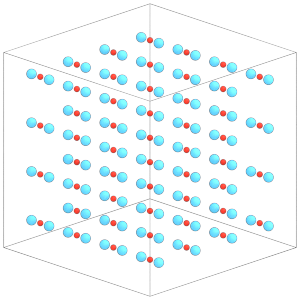

In [12]:
logger = hoomd.logging.Logger(['particle','constraint'])
gsd_oper = hoomd.write.GSD(trigger=hoomd.trigger.Periodic(int(100)), filename='active_torque.gsd',logger=logger,mode='wb',dynamic=['momentum','property'],filter=hoomd.filter.All())

simulation.operations += gsd_oper

simulation.state.thermalize_particle_momenta(filter=filter_free, kT=kT)
simulation.run(0)
render(simulation.state.get_snapshot())

Since only an **active torque** has been applied with no translational force or thermal noise, we expect each rigid body to undergo pure rotation around its center of mass, without drifting or translating.
Run the simulation. Then observe the final configuration to confirm that the particles are spinning in place as expected.

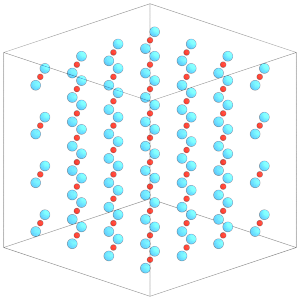

In [13]:
simulation.run(50000)
gsd_oper.flush()
render(simulation.state.get_snapshot())